In [1]:
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [3]:
df = pd.read_csv("Coffe_sales (2).csv")

df.head()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000


In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   object 
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   object 
 4   Time_of_Day  3547 non-null   object 
 5   Weekday      3547 non-null   object 
 6   Month_name   3547 non-null   object 
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   object 
 10  Time         3547 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 304.9+ KB


hour_of_day    0
cash_type      0
money          0
coffee_name    0
Time_of_Day    0
Weekday        0
Month_name     0
Weekdaysort    0
Monthsort      0
Date           0
Time           0
dtype: int64

In [6]:
df['Date'] = pd.to_datetime(df['Date'])


In [7]:
df['Time'] = pd.to_datetime(df['Time'])

In [8]:
df.duplicated().sum()
df = df.drop_duplicates()

In [9]:
df.rename(columns={
    'money': 'Sales',
    'coffee_name': 'Product'
}, inplace=True)

In [10]:
total_sales = df['Sales'].sum()
print("Total Revenue:", total_sales)

Total Revenue: 112245.57999999999


The analysis shows that Latte generates the highest revenue, indicating strong customer preference. This suggests the business should prioritize stocking this product and possibly expand variations to increase sales further.

In [11]:
product_sales = df.groupby('Product')['Sales'].sum().sort_values(ascending=False)
print(product_sales)

Product
Latte                  26875.30
Americano with Milk    24751.12
Cappuccino             17439.14
Americano              14650.26
Hot Chocolate           9933.46
Cocoa                   8521.16
Cortado                 7384.86
Espresso                2690.28
Name: Sales, dtype: float64


In [13]:
payment_sales = df.groupby('cash_type')['Sales'].sum()
print(payment_sales)

cash_type
card    112245.58
Name: Sales, dtype: float64


Most transactions are made using Card, indicating customer preference for this payment method. This suggests the business should ensure smooth processing for this option to improve customer experience.

In [14]:
time_sales = df.groupby('Time_of_Day')['Sales'].sum()
print(time_sales)

Time_of_Day
Afternoon    38130.04
Morning      35929.20
Night        38186.34
Name: Sales, dtype: float64


Sales are highest during the Night, indicating peak customer activity. The business can use this insight to schedule staff efficiently and prepare inventory ahead of peak periods.

In [15]:
hour_sales = df.groupby('hour_of_day')['Sales'].sum()
print(hour_sales)

hour_of_day
6       149.40
7      2846.02
8      7017.88
9      7264.28
10    10198.52
11     8453.10
12     7419.62
13     7028.76
14     7173.80
15     7476.02
16     9031.84
17     7659.76
18     7162.60
19     7751.96
20     5578.92
21     6397.94
22     3635.16
Name: Sales, dtype: float64


Sales peak around the 10th hour of the day, suggesting a rush period. This could be linked to work breaks or commuting patterns, and the business can use this information to optimize staffing and service speed.

In [16]:
weekday_sales = df.groupby('Weekday')['Sales'].sum()
print(weekday_sales)

Weekday
Fri    16802.66
Mon    17363.10
Sat    14733.52
Sun    13336.06
Thu    16091.40
Tue    18168.38
Wed    15750.46
Name: Sales, dtype: float64


Certain days such as Tuesday and Monday show higher sales, indicating increased customer demand. The business could introduce promotions on slower days to balance revenue.

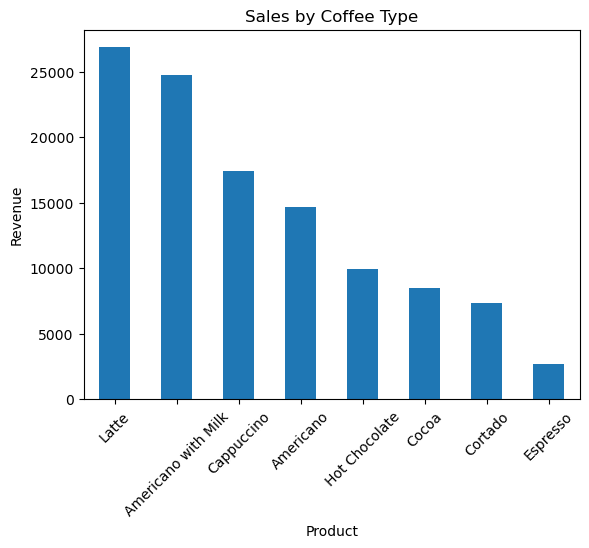

In [17]:
product_sales.plot(kind='bar')
plt.title("Sales by Coffee Type")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

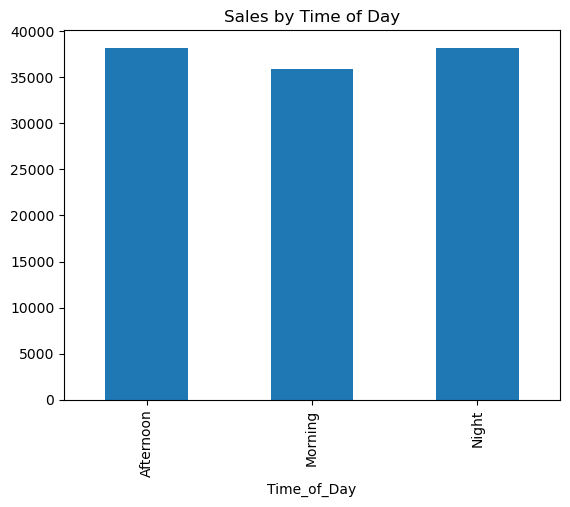

In [18]:
time_sales.plot(kind='bar')
plt.title("Sales by Time of Day")
plt.show()

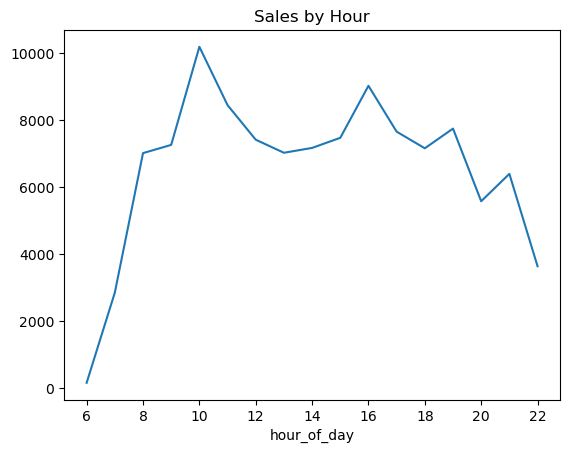

In [19]:
hour_sales.plot()
plt.title("Sales by Hour")
plt.show()

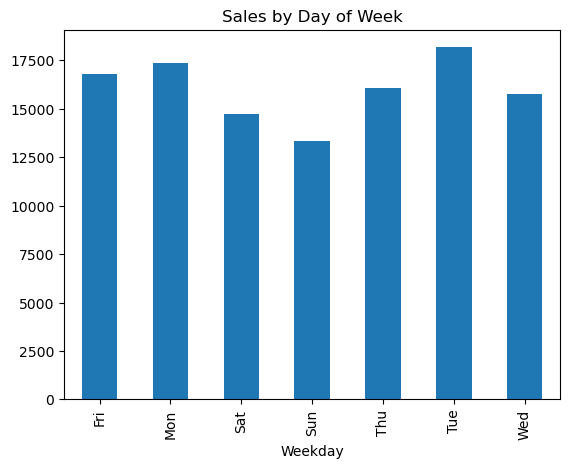

In [20]:
weekday_sales.plot(kind='bar')
plt.title("Sales by Day of Week")
plt.show()